# Example 6 — Power tracking

WindGym can train agents that *follow* a farm power reference (think of a grid
or AGC dispatch command) instead of maximizing power. Setting
`Track_power: true`:

- replaces the power reward with a **tracking reward** (this requires
  `Power_reward: "None"` — the two objectives are mutually exclusive),
- draws a **reference trajectory** per episode — by default a constant,
  feasible setpoint; a custom `power_ref_function` gives ramps, steps, or
  stochastic signals,
- adds farm-level **observations**: the current setpoint, the tracking error,
  and optionally a preview of future setpoints.

Derating is the natural actuator (see *Example 5*), so this notebook uses the
DTU 10MW derating surrogate and a derate-only agent. We

1. build a tracking environment and inspect its info dict,
2. look at the default reference sampler,
3. track the reference with a simple proportional derate controller,
4. use a custom ramp `power_ref_function`.

Full reference: `Docs/docs/power_tracking.md`.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from py_wake.examples.data.dtu10mw._dtu10mw import DTU10MW
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import DensityScale, PowerCtNDTabular

# Reduced derating surrogate (power + ct) shipped with WindGym; see Example 5.
SURROGATE_NC = Path("data/dtu10mw_derating_yaw_surrogate.nc")
assert SURROGATE_NC.exists(), "run this notebook from the examples/ directory"


def make_derating_dtu10mw(nc_path=SURROGATE_NC) -> WindTurbine:
    ds = xr.load_dataset(nc_path).transpose("ws", "yaw", "derating")
    ref = DTU10MW()

    pctf = PowerCtNDTabular(
        input_keys=["ws", "yaw", "derate"],
        value_lst=[ds.ws.values, ds.yaw.values.astype(float), ds.derating.values],
        power_arr=ds.power.values,
        power_unit="W",
        ct_arr=ds.ct.values,
        default_value_dict={"yaw": 0.0, "derate": 0.0},
        additional_models=[DensityScale(1.225)],
    )
    for gi in pctf.interp:
        gi.bounds = "limit"

    return WindTurbine(
        name="DTU10MW",
        diameter=ref.diameter(),
        hub_height=ref.hub_height(),
        powerCtFunction=pctf,
    )


wt = make_derating_dtu10mw()
print(f"D = {wt.diameter():.1f} m, rated ~ {float(wt.power(12.0)) / 1e6:.1f} MW")

D = 178.3 m, rated ~ 10.0 MW


/tmp/ipykernel_94407/683420891.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"D = {wt.diameter():.1f} m, rated ~ {float(wt.power(12.0)) / 1e6:.1f} MW")


## 1. A tracking environment

The config below enables tracking (`Track_power` + `Power_reward: "None"`) on
a 3-turbine row with a **derate-only** agent (`yaw_action: false`). The
`track_def` section is optional; here we narrow the default sampler to
15–35% of the episode freestream farm power. That keeps every setpoint below
the *waked* greedy farm power (≈ 41% of freestream for this 3-turbine row at
5D), so a derate-only controller can always reach it — higher references
would need wake steering on top.

We use the fast steady-state pywake backend and a fixed 9 m/s inflow so the
tracking behaviour is easy to see.

In [2]:
from WindGym import WindFarmEnv

D = wt.diameter()
N_TURB = 3


def make_config(**overrides):
    config = {
        "ActionMethod": "wind",
        "Track_power": True,
        "yaw_action": False,  # derate-only agent
        "derate_action": True,
        "derate_min": 0.0,
        "derate_max": 0.8,
        "derate_method": "absolute",
        "track_def": {
            "Track_reward": "abs",  # r = -|P_farm - P_ref| / (rated farm power)
            "track_ref_range": [0.15, 0.35],
            "track_obs_setpoint": True,
            "track_obs_error": True,
            "track_obs_preview": 0,
        },
        "farm": {"yaw_min": -30, "yaw_max": 30},
        "wind": {
            "ws_min": 9.0,
            "ws_max": 9.0,
            "TI_min": 0.06,
            "TI_max": 0.06,
            "wd_min": 270.0,
            "wd_max": 270.0,
        },
        "act_pen": {"action_penalty": 0.0, "action_penalty_type": "change"},
        "power_def": {"Power_reward": "None", "Power_avg": 5, "Power_scaling": 1.0},
        "mes_level": {
            "turb_ws": True,
            "turb_wd": False,
            "turb_TI": False,
            "turb_power": True,
            "farm_ws": False,
            "farm_wd": False,
            "farm_TI": False,
            "farm_power": True,
        },
        "ws_mes": {
            "ws_current": True,
            "ws_rolling_mean": False,
            "ws_history_N": 1,
            "ws_history_length": 10,
            "ws_window_length": 10,
        },
        "wd_mes": {
            "wd_current": False,
            "wd_rolling_mean": False,
            "wd_history_N": 0,
            "wd_history_length": 10,
            "wd_window_length": 10,
        },
        "yaw_mes": {
            "yaw_current": False,
            "yaw_rolling_mean": False,
            "yaw_history_N": 0,
            "yaw_history_length": 10,
            "yaw_window_length": 10,
        },
        "power_mes": {
            "power_current": True,
            "power_rolling_mean": False,
            "power_history_N": 1,
            "power_history_length": 10,
            "power_window_length": 10,
        },
    }
    config.update(overrides)
    return config


def make_env(config=None, **kwargs):
    kwargs.setdefault("max_time_steps", 150)
    return WindFarmEnv(
        turbine=wt,
        x_pos=np.arange(N_TURB) * 5 * D,
        y_pos=np.zeros(N_TURB),
        config=config if config is not None else make_config(),
        backend="pywake",
        reset_init=False,
        **kwargs,
    )


env = make_env()
obs, info = env.reset(seed=0)
print("observation vector length:", env.observation_space.shape[0])
print("action vector (derate per turbine):", env.action_space.shape[0])
print(f"power reference:  {info['Power reference'] / 1e6:6.2f} MW")
print(f"tracking error:   {info['Tracking error'] / 1e6:+6.2f} MW")

max_time_steps=150: episode length fixed to 150 env steps (150 s of simulation); n_passthrough is ignored.
observation vector length: 12
action vector (derate per turbine): 3
power reference:    2.24 MW
tracking error:    +3.70 MW


### The default reference sampler

Without a `power_ref_function`, each episode gets a **constant** setpoint,
uniform in `track_ref_range` times the episode *freestream* farm power
(`turbine.power(ws) * n_turb`) — feasible by construction. The rated
(nameplate) farm power is only used to normalize the reward and the
observations.

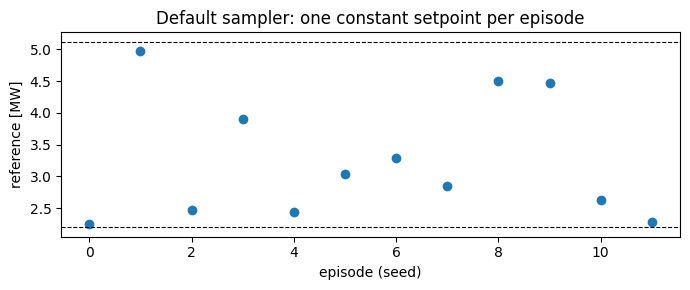

In [3]:
setpoints = []
for seed in range(12):
    _, info_ = env.reset(seed=seed)
    setpoints.append(info_["Power reference"])

farm_free = env.rated_power * env.n_turb  # freestream farm power at 9 m/s

plt.figure(figsize=(7, 3))
plt.plot(np.array(setpoints) / 1e6, "o")
for frac in (0.15, 0.35):
    plt.axhline(frac * farm_free / 1e6, color="k", ls="--", lw=0.8)
plt.xlabel("episode (seed)")
plt.ylabel("reference [MW]")
plt.title("Default sampler: one constant setpoint per episode")
plt.tight_layout()

## 2. Tracking with a simple derate controller

No learning yet — just uniform proportional feedback in derate space:
overproduce → derate more, underproduce → derate less. This is the sanity
check that the environment closes the loop: the farm power should converge to
the reference and the `abs` reward should approach 0.

(The controller inverts the env's affine action → derate mapping, so it can
command an absolute derate level directly.)

In [4]:
P_NORM = env.maxturbpower * env.n_turb  # rated farm power = reward normalization


class DerateTrackingController:
    """Uniform proportional derate controller (not an RL agent)."""

    def __init__(self, env, gain=2.0):
        self.dmin, self.dmax = env.derate_min, env.derate_max
        self.gain = gain
        self.derate = 0.0

    def act(self, info):
        err = info["Tracking error"]  # P_farm - P_ref [W]
        self.derate = float(
            np.clip(self.derate + self.gain * err / P_NORM, self.dmin, self.dmax)
        )
        # invert the affine [-1, 1] -> [derate_min, derate_max] action mapping
        action = 2 * (self.derate - self.dmin) / (self.dmax - self.dmin) - 1
        return np.full(env.n_turb, action, dtype=np.float32)


def rollout(env, seed=0, n_steps=150):
    _, info = env.reset(seed=seed)
    ctrl = DerateTrackingController(env)
    log = {"p_farm": [], "p_ref": [], "reward": [], "derate": []}
    for _ in range(n_steps):
        _, reward, _, truncated, info = env.step(ctrl.act(info))
        log["p_farm"].append(info["Power agent"])
        log["p_ref"].append(info["Power reference"])
        log["reward"].append(reward)
        log["derate"].append(info["derate agent"].mean())
        if truncated:
            break
    return {k: np.asarray(v) for k, v in log.items()}


def plot_rollout(log, title):
    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    axes[0].plot(log["p_farm"] / 1e6, label="$P_{farm}$")
    axes[0].plot(log["p_ref"] / 1e6, "k--", label="$P_{ref}$")
    axes[0].set_ylabel("power [MW]")
    axes[0].set_title(title)
    axes[0].legend()
    axes[1].plot(log["reward"], color="tab:orange")
    axes[1].set_ylabel("reward (abs form)")
    axes[2].plot(log["derate"], color="tab:green")
    axes[2].set_ylabel("mean derate")
    axes[2].set_xlabel("env step")
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout()

max_time_steps=150: episode length fixed to 150 env steps (150 s of simulation); n_passthrough is ignored.


final tracking error: +0.000 MW
final reward:         -0.0000


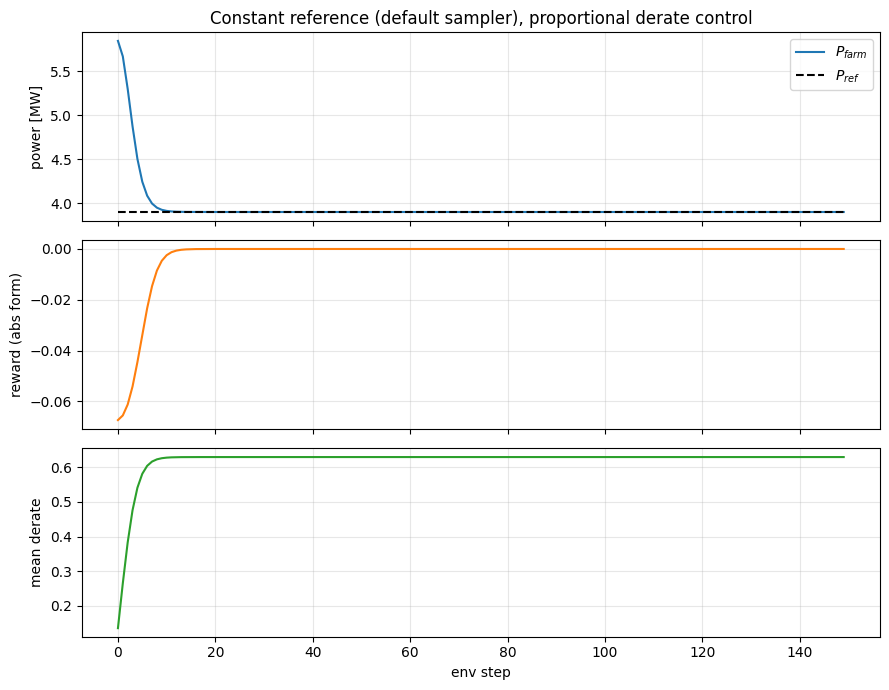

In [5]:
log = rollout(make_env(), seed=3)
plot_rollout(log, "Constant reference (default sampler), proportional derate control")
print(f"final tracking error: {(log['p_farm'][-1] - log['p_ref'][-1]) / 1e6:+.3f} MW")
print(f"final reward:         {log['reward'][-1]:+.4f}")

The reward starts negative (the farm greedily overproduces relative to the
setpoint), then approaches 0 as the controller derates the turbines to match
the reference. Note the reward compares **window means** (`Power_avg` steps)
of farm power and reference — not instantaneous values — so a reference step
change never causes an unavoidable one-step penalty spike.

## 3. Custom reference: `power_ref_function`

For time-varying references, pass a callable `(t_seconds, env) -> watts` to
the constructor, mirroring `wd_function`. It is evaluated once per env step
(every `delay` seconds) at reset, and may use `env.np_random`, `env.ws`,
`env.n_turb`, `env.rated_power`. Below: a ramp from 15% to 35% of the episode
freestream farm power over the first 100 s.

With `track_obs_preview: k` in `track_def`, the agent additionally observes
the next *k* reference values — useful for anticipating ramps instead of
reacting to them.

max_time_steps=150: episode length fixed to 150 env steps (150 s of simulation); n_passthrough is ignored.


final tracking error: +0.000 MW


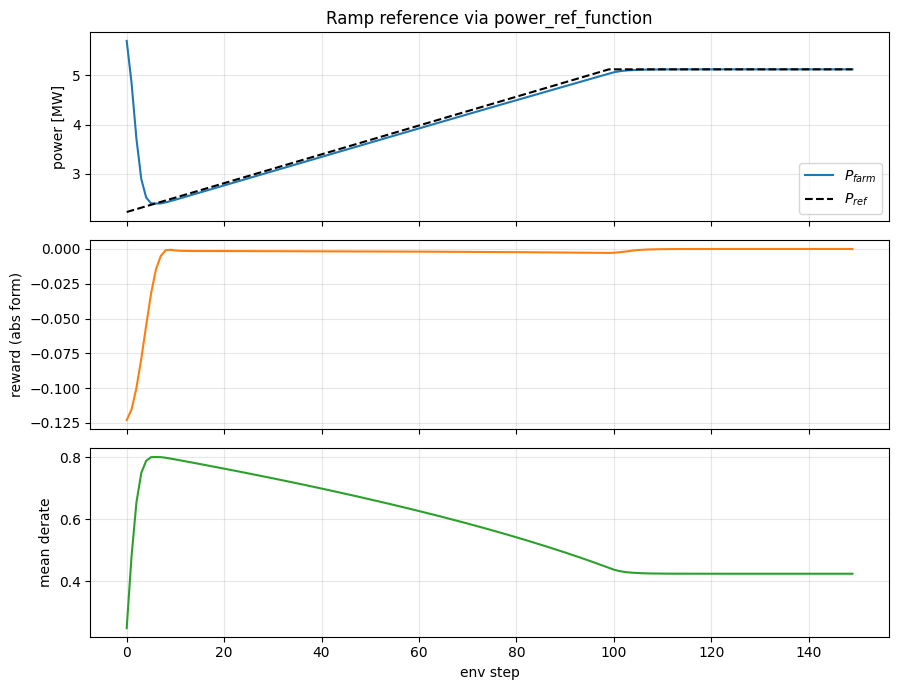

In [6]:
def ramp(t, env):
    """15% -> 35% of the episode freestream farm power over 100 s, then hold."""
    frac = 0.15 + 0.20 * min(t / 100.0, 1.0)
    return frac * env.rated_power * env.n_turb


env_ramp = make_env(power_ref_function=ramp)
log = rollout(env_ramp, seed=3)
plot_rollout(log, "Ramp reference via power_ref_function")
print(f"final tracking error: {(log['p_farm'][-1] - log['p_ref'][-1]) / 1e6:+.3f} MW")

## Notes

- **Reward forms**: `Track_reward: "abs"` gives `r = -|error| / P_norm`
  (≤ 0); `"gaussian"` gives `r = exp(-(error / (sigma * P_norm))^2)` in
  (0, 1] with width `track_sigma` (default 0.1). `P_norm` is the rated
  (nameplate) farm power, fixed per farm.
- **No baseline needed**: tracking does not require `Baseline_comp`, and the
  reference is *not* clipped to the greedy-available power — exceeding greedy
  power via wake steering is a legitimate way to reach a high reference.
- **Evaluation**: `AgentEval`/`AgentEvalFast` datasets gain `power_ref`,
  `track_err` (time series) and `track_mae` (per-condition scalar) when the
  env has `Track_power` set.
- **Multi-agent**: `WindFarmEnvMulti` raises `NotImplementedError` with
  `Track_power` for now.
- **Seeding**: enabling tracking adds one RNG draw at reset, so tracking
  episodes are reproducible per seed but not observation-identical to a
  non-tracking env with the same seed.